# Data Preprocessing-Before Building Machine learnig model

#STEPS of preprocessing of data\
step:1]- Import neccessary library\
step:2]- Read Dataset\
step:3]- sanity check of data\
step:4]- Exploratory Data Analysis(EDA)\
step:5] -Missing Value treatments\
step:6]- Outliers treatments\
step:7]- Duplicates & Garbage value treatments\
step:8]- Normalization\
step:9]- Encoding of data

### step:1]- Import neccessary library


In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option('display.max_columns', None)

### step:2]- Read Dataset


In [37]:
df=pd.read_csv(r"E:\saudi-arabia-real-estate-dataset\sa_listings_cleaned.csv")

In [38]:
# 1. مسار السكني (Residential)
residential_types = ['Villa', 'Apartment', 'House', 'Floor', 'Building', 'Furnished Apartment']
df_residential = df[df['property_category'].isin(residential_types)].copy()

# تقسيم الداتا السكنية إلى بيع وإيجار
df_res_sale = df_residential[df_residential['transaction_type'] == 'Sale'].copy()
df_res_rent = df_residential[df_residential['transaction_type'] == 'Rent'].copy()

# حذف الأعمدة غير المطلوبة في داتا البيع السكنية
df_res_sale.drop(columns=['transaction_type', 'rent_period'], inplace=True, errors='ignore')

# 2. مسار الأراضي (Land)
df_land = df[df['property_category'] == 'Land'].copy()

# 3. مسار الترفيهي (Entertainment)
entertainment_types = ['Chalet', 'Esteraha', 'Campsite']
df_entertainment = df[df['property_category'].isin(entertainment_types)].copy()

print(f"Residential: {len(df_residential)} rows")
print(f"   - Residential Sale: {len(df_res_sale)} rows")
print(f"   - Residential Rent: {len(df_res_rent)} rows")
print(f"Land: {len(df_land)} rows")
print(f"Entertainment: {len(df_entertainment)} rows")

Residential: 409084 rows
   - Residential Sale: 307706 rows
   - Residential Rent: 101378 rows
Land: 192060 rows
Entertainment: 10429 rows


In [39]:
#head
df_res_sale.head()

,id,createdAt,month,week_day,property_category,beds,livings,wc,area,street_width,age,ketchen,location.lat,location.lng,province,city_id,city,city_en,district_id,district,district_en,price
7,14155,2023-01-01,Jan,Sun,Villa,5.0,3.0,5.0,810.0,15.0,0.0,1.0,21.612269,39.138396,Makkah,66,جدة,Jeddah,3608,حي النهضة,Al Nahda neighborhood,7300000.0
11,24578,2023-01-01,Jan,Sun,Villa,5.0,1.0,3.0,400.0,30.0,0.0,1.0,21.386495,39.784993,Makkah,94,مكة المكرمة,Makkah,3766,حي الملك فهد,King Fahd neighborhood,1650000.0
13,24582,2023-01-01,Jan,Sun,Building,0.0,0.0,0.0,376.0,30.0,15.0,0.0,21.435731,39.849560,Makkah,94,مكة المكرمة,Makkah,3764,حي المعابدة,Al Maabdah neighborhood,18000000.0
16,40278,2023-01-01,Jan,Sun,Building,0.0,0.0,0.0,720.0,15.0,25.0,0.0,21.408780,39.789310,Makkah,94,مكة المكرمة,Makkah,3714,حي الرصيفة,Rusaifa neighborhood,5500000.0
19,50786,2023-01-01,Jan,Sun,Building,0.0,0.0,0.0,660.0,15.0,27.0,0.0,21.596930,39.132340,Makkah,66,جدة,Jeddah,3496,حي الزهراء,Al Zahra neighborhood,15000000.0


In [40]:
#tail
df_res_sale.tail()

,id,createdAt,month,week_day,property_category,beds,livings,wc,area,street_width,age,ketchen,location.lat,location.lng,province,city_id,city,city_en,district_id,district,district_en,price
631918,5461528,2023-07-07,Jul,Fri,Villa,5.0,2.0,5.0,513.0,NaN,NaN,1.0,27.415503,41.573215,Hail,67,حائل,Hail,2056,حي النقرة,Al Naqra neighborhood,1450000.0
631922,5461567,2023-07-07,Jul,Fri,Building,NaN,NaN,NaN,690.0,NaN,NaN,NaN,21.502218,39.785602,Makkah,94,مكة المكرمة,Makkah,3686,حي البحيرات,Al Buhayrat neighborhood,5500000.0
631923,5461569,2023-07-07,Jul,Fri,Building,NaN,NaN,NaN,1801.0,NaN,NaN,NaN,24.480719,39.631348,Madinah,41,المدينة المنورة,Madinah,2992,حي العريض,Al Areed neighborhood,20000000.0
631926,5461592,2023-07-07,Jul,Fri,Apartment,NaN,NaN,NaN,155.0,NaN,NaN,NaN,24.771925,46.694363,Riyadh,21,الرياض,Riyadh,404,حي التعاون,At Taawun neighborhood,1249000.0
631928,5461602,2023-07-07,Jul,Fri,Villa,7.0,2.0,4.0,612.0,NaN,NaN,1.0,24.573622,46.700851,Riyadh,21,الرياض,Riyadh,478,حي الشفا,Al Shifa neighborhood,1200000.0


### step:3]- sanity check of data


In [41]:
#shape
df_res_sale.shape

(307706, 22)

In [42]:
#info()
df_res_sale.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307706 entries, 7 to 631928
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 307706 non-null  int64  
 1   createdAt          307706 non-null  object 
 2   month              307706 non-null  object 
 3   week_day           307706 non-null  object 
 4   property_category  307706 non-null  object 
 5   beds               283192 non-null  float64
 6   livings            283348 non-null  float64
 7   wc                 283343 non-null  float64
 8   area               307699 non-null  float64
 9   street_width       304447 non-null  float64
 10  age                282298 non-null  float64
 11  ketchen            271541 non-null  float64
 12  location.lat       307706 non-null  float64
 13  location.lng       307706 non-null  float64
 14  province           307706 non-null  object 
 15  city_id            307706 non-null  int64  
 16  city   

In [43]:
#finding missing value
df_res_sale.isnull().sum()

id                       0
createdAt                0
month                    0
week_day                 0
property_category        0
beds                 24514
livings              24358
wc                   24363
area                     7
street_width          3259
age                  25408
ketchen              36165
location.lat             0
location.lng             0
province                 0
city_id                  0
city                     0
city_en                  0
district_id              0
district                 0
district_en              0
price                    0
dtype: int64

In [44]:
#Percentage of missing values
df_res_sale.isnull().sum()/df_res_sale.shape[0]*100

id                    0.000000
createdAt             0.000000
month                 0.000000
week_day              0.000000
property_category     0.000000
beds                  7.966695
livings               7.915998
wc                    7.917623
area                  0.002275
street_width          1.059128
age                   8.257233
ketchen              11.753102
location.lat          0.000000
location.lng          0.000000
province              0.000000
city_id               0.000000
city                  0.000000
city_en               0.000000
district_id           0.000000
district              0.000000
district_en           0.000000
price                 0.000000
dtype: float64

In [45]:
#finding duplicates
df_res_sale.duplicated().sum()

0

In [46]:
#identifiying garbage values
for i in df_res_sale.select_dtypes(include="object").columns:
    print(df_res_sale[i].value_counts())
    print("****"*10)

createdAt
2023-01-01    161298
2023-03-02     31057
2023-02-02     25672
2023-03-31     23552
2023-05-03     18804
2023-06-05     15234
2023-06-04     13631
2023-07-07      8612
2023-04-01      3548
2023-05-14      3024
2023-01-04      1365
2023-01-03      1249
2023-01-02       660
Name: count, dtype: int64
****************************************
month
Jan    164572
Mar     54609
Jun     28865
Feb     25672
May     21828
Jul      8612
Apr      3548
Name: count, dtype: int64
****************************************
week_day
Sun    177953
Thu     56729
Fri     32164
Wed     20169
Mon     15894
Sat      3548
Tue      1249
Name: count, dtype: int64
****************************************
property_category
Villa        187200
Apartment     82178
Building      24636
Floor          9783
House          3909
Name: count, dtype: int64
****************************************
province
Riyadh              157652
Makkah               75214
Eastern              44603
Aseer                 9670
Mad

In [47]:
# كود ذكي للكشف عن القيم المشكوك فيها (Garbage Detection)
garbage_report = {}

for col in df_res_sale.select_dtypes(include="object").columns:
    counts = df_res_sale[col].value_counts()
    
    # هنطلع القيم اللي اتكررت أقل من 3 مرات (احتمال كبير تكون غلطة إملائية)
    rare_values = counts[counts < 3].index.tolist()
    
    # هنطلع الكلمات اللي فيها رموز مش حروف (زي ? أو #)
    suspicious_chars = [val for val in counts.index if any(char in str(val) for char in ['?', '#', '!', '*'])]
    
    if rare_values or suspicious_chars:
        garbage_report[col] = {
            "Rare Values (Possible Typos)": rare_values,
            "Suspicious Symbols": suspicious_chars
        }

# عرض التقرير
if not garbage_report:
    print("✨ البيانات نظيفة زي الفل مفيش قيم غريبة واضحة!")
else:
    for col, issues in garbage_report.items():
        print(f"🔍 العمود: 【{col}】")
        if issues["Rare Values (Possible Typos)"]:
            print(f"   - قيم نادرة (ممكن تكون غلطات): {issues['Rare Values (Possible Typos)']}")
        if issues["Suspicious Symbols"]:
            print(f"   - رموز مشبوهة: {issues['Suspicious Symbols']}")
        print("-" * 30)

🔍 العمود: 【city】
   - قيم نادرة (ممكن تكون غلطات): ['املج', 'المبرز', 'الكامل', 'العيون', 'الوديعة']
------------------------------
🔍 العمود: 【city_en】
   - قيم نادرة (ممكن تكون غلطات): ['Umluj', 'Al Mubarraz', 'Al Kamil', 'Al Oyun', 'Al Wadiah']
------------------------------
🔍 العمود: 【district】
   - قيم نادرة (ممكن تكون غلطات): ['حي الحسين', 'حي الطف', 'حي الوهلان', 'حي المحمديه', 'حي خب القصبا', 'حي السر', 'حي العصبة', 'حي هداج', 'حي المنشية القديمة', 'حي قاعدة الملك فيصل البحرية', 'حي الكليبية', 'حي الشفق', 'حي مخطط المنح الخاصة', 'حي جنوب الدرعية', 'حي الشروفية', 'حي الحازم', 'حي خب الجطيلي', 'حي سوق الليل', 'حي حاكمية الدغادير', 'حي حكامية العز', 'حي القرين', 'حي وسط ثول', 'حي صدر الغربية', 'حي فليج', 'حي الجرن', 'حي المجيدية', 'حي مخطط الامل', 'حي الشورى', 'حي الكامل', 'حي المبرز', 'حي شمال النفل', 'حي العرق الجنوبي', 'حي السبيل', 'حي مخطط أ', 'حي البهجة', 'حي المطلع', 'حي الطوير', 'حي البديع والقرفي', 'حي المنتزه الجنوبي', 'حي الجابرية 2', 'حي الدغادير', 'حي العوامية', 'حي الم

### step:4]- Exploratory Data Analysis(EDA)


In [48]:
#descriptive statistics
df_res_sale.describe().T

,count,mean,std,min,25%,50%,75%,max
id,307706.0,4.934781e+06,4.286265e+05,14155.000000,4.766584e+06,5.027680e+06,5.225642e+06,5.461602e+06
beds,283192.0,4.699660e+00,1.196295e+00,0.000000,4.000000e+00,5.000000e+00,5.000000e+00,7.000000e+00
livings,283348.0,1.940674e+00,1.058374e+00,0.000000,1.000000e+00,2.000000e+00,3.000000e+00,7.000000e+00
wc,283343.0,4.159256e+00,9.775482e-01,0.000000,3.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00
area,307699.0,3.749242e+02,1.544263e+03,1.000000,2.080000e+02,3.000000e+02,4.000000e+02,6.252500e+05
street_width,304447.0,2.063369e+01,9.443332e+00,0.000000,1.500000e+01,2.000000e+01,2.300000e+01,1.000000e+02
age,282298.0,3.386538e+00,7.726959e+00,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,3.600000e+01
ketchen,271541.0,9.508030e-01,2.162795e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
location.lat,307706.0,2.395270e+01,2.100624e+00,-30.488082,2.177886e+01,2.465034e+01,2.485863e+01,3.750604e+01
location.lng,307706.0,4.488827e+01,3.773828e+00,-2.074926,3.983256e+01,4.661185e+01,4.677508e+01,5.123236e+01


In [49]:
df_res_sale.describe(include="object").T

,count,unique,top,freq
createdAt,307706,13,2023-01-01,161298
month,307706,7,Jan,164572
week_day,307706,7,Sun,177953
property_category,307706,5,Villa,187200
province,307706,13,Riyadh,157652
city,307706,97,الرياض,153116
city_en,307706,97,Riyadh,153116
district,307706,933,حي طويق,14827
district_en,307706,925,Tuwaiq neighborhood,14827


In [50]:
df_res_sale.select_dtypes(include="number").columns

Index(['id', 'beds', 'livings', 'wc', 'area', 'street_width', 'age', 'ketchen',
       'location.lat', 'location.lng', 'city_id', 'district_id', 'price'],
      dtype='object')

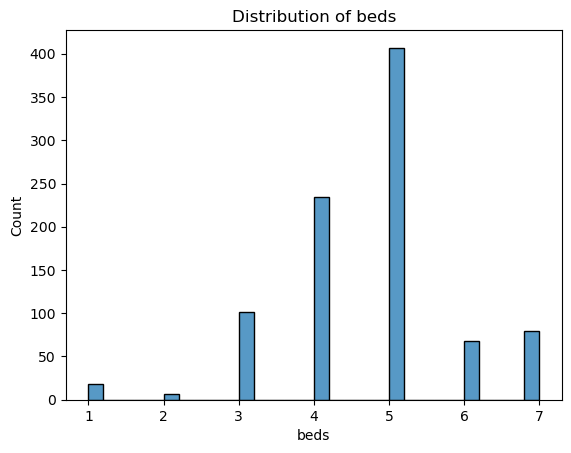

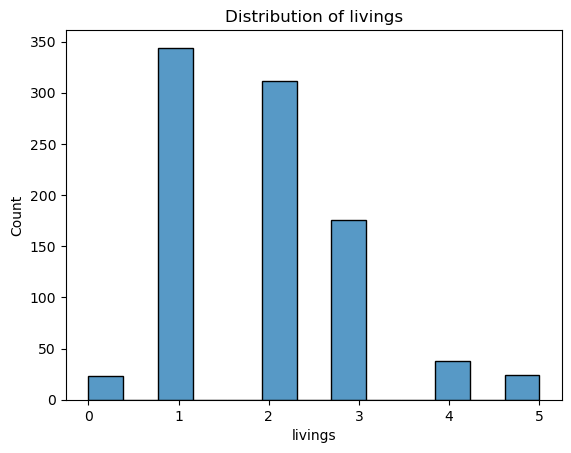

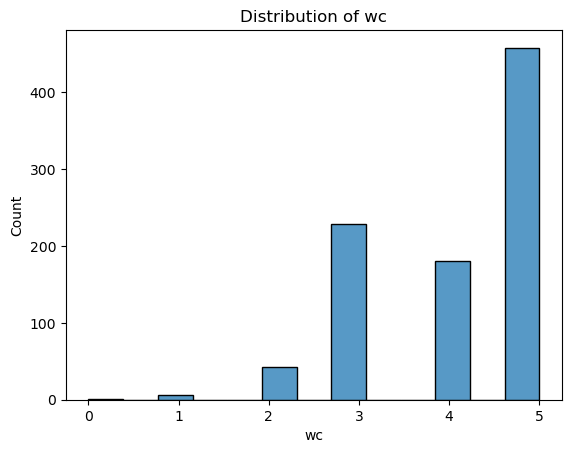

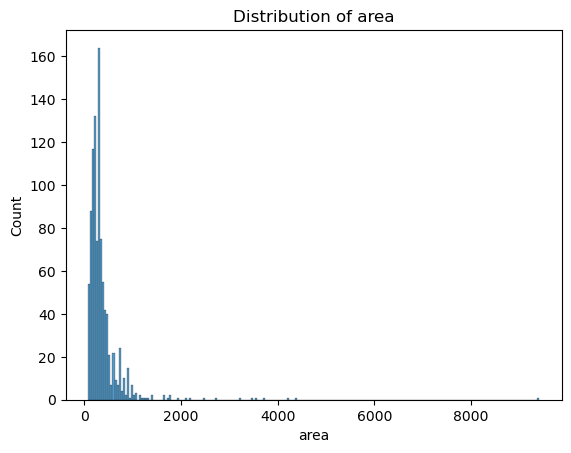

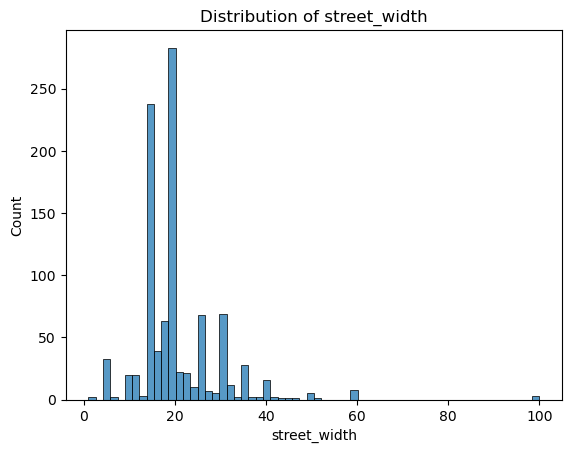

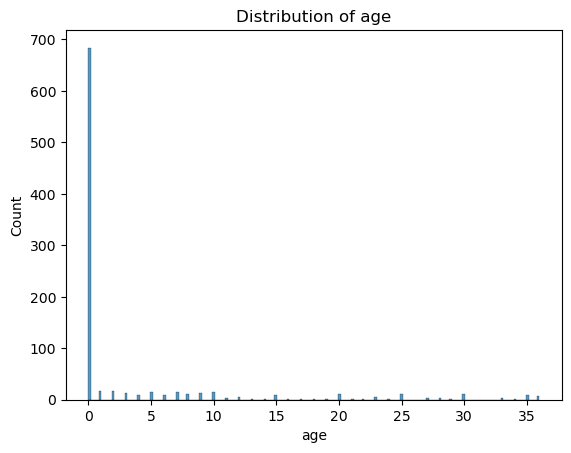

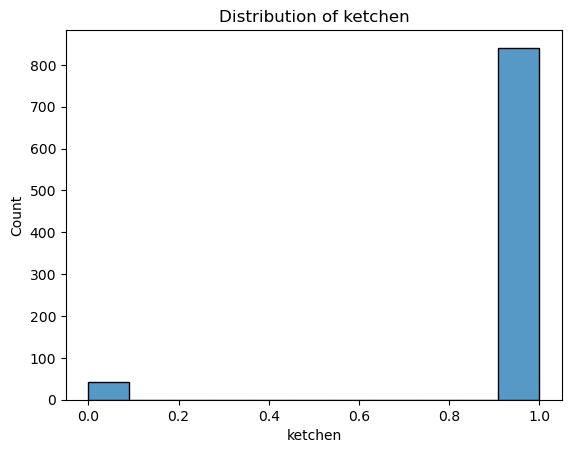

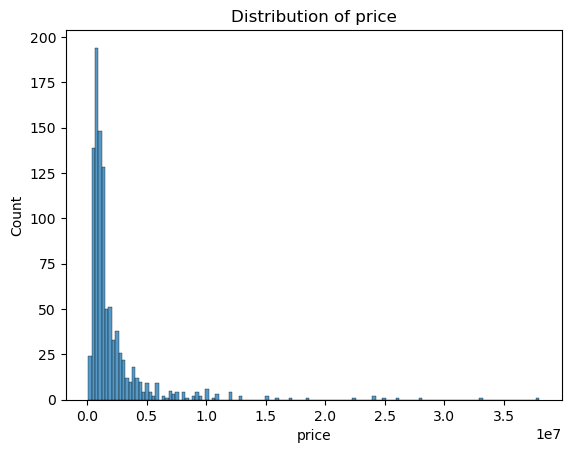

In [51]:
# هناخد عينة 1000 سطر بس عشان الرسم يكون سريع 
df_sample = df_res_sale.sample(n=1000) 

for i in ['beds', 'livings', 'wc', 'area', 'street_width', 'age', 'ketchen', 'price']:
    sns.histplot(data=df_sample, x=i)
    plt.title(f'Distribution of {i}')
    plt.show()

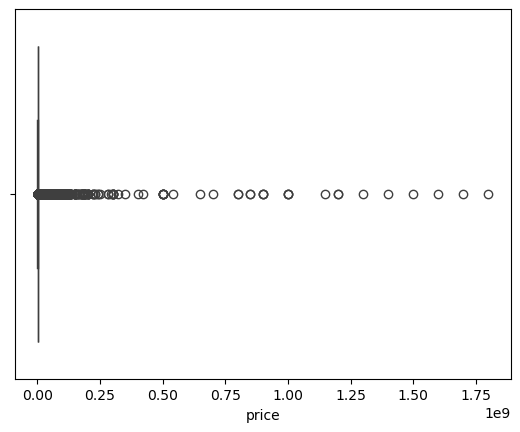

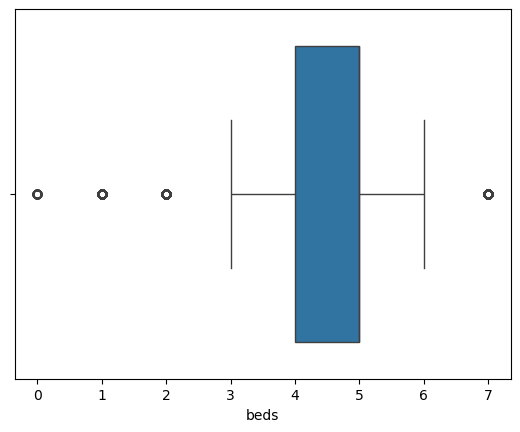

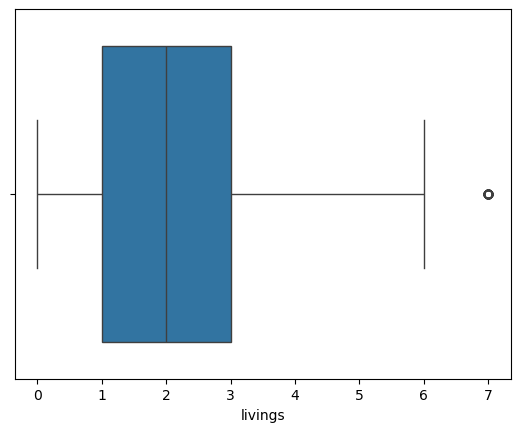

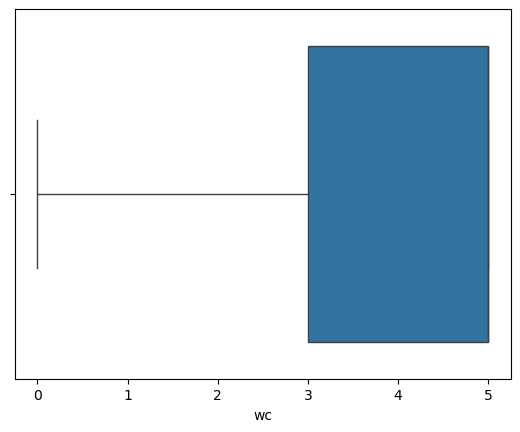

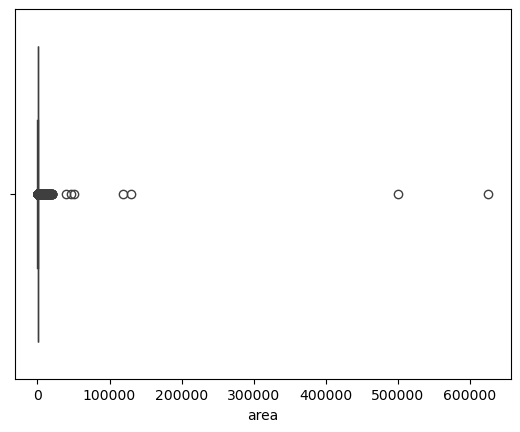

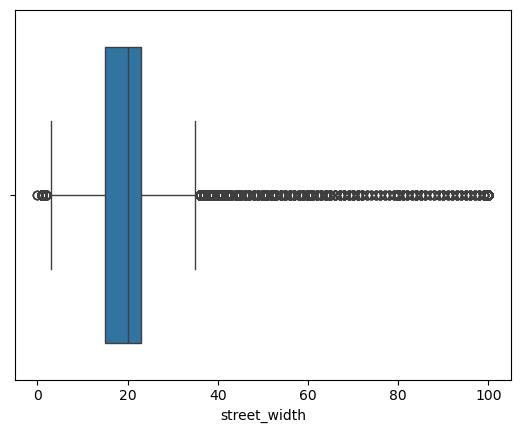

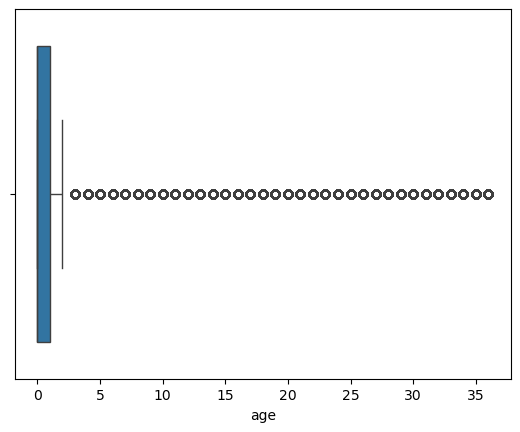

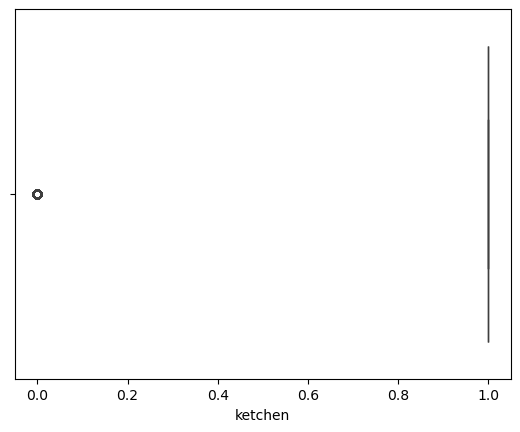

In [52]:
#Boxplot-to-identify Outliers
for i in ['price', 'beds', 'livings', 'wc', 'area', 'street_width', 'age', 'ketchen']:
    sns.boxplot(data=df_res_sale,x=i)
    plt.show()

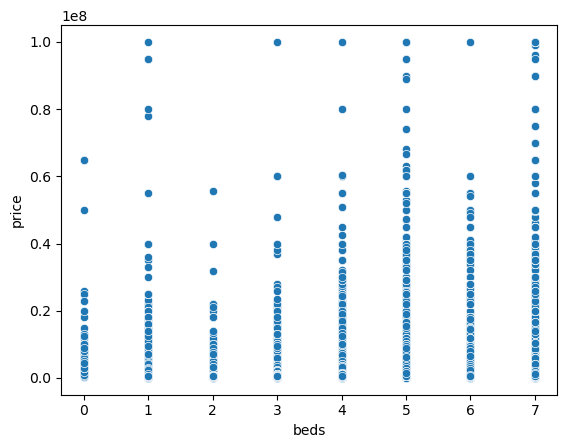

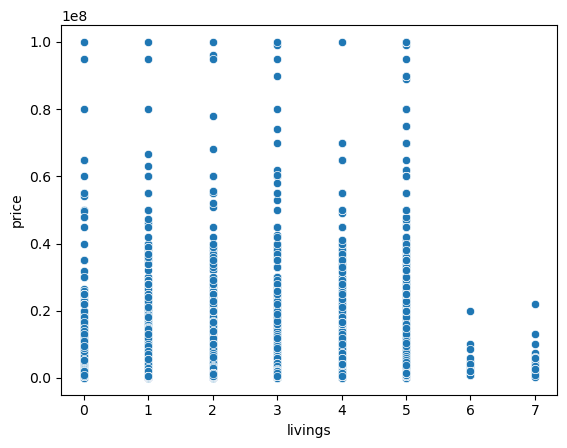

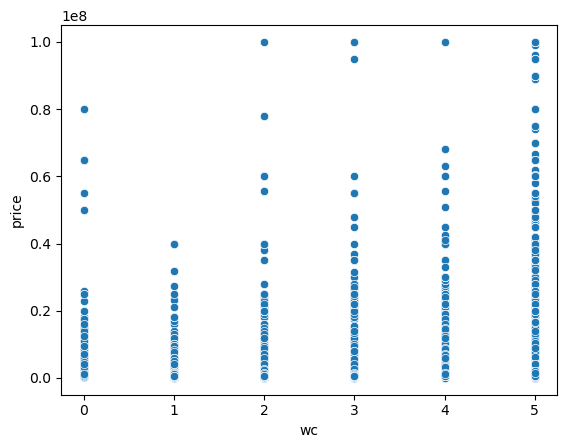

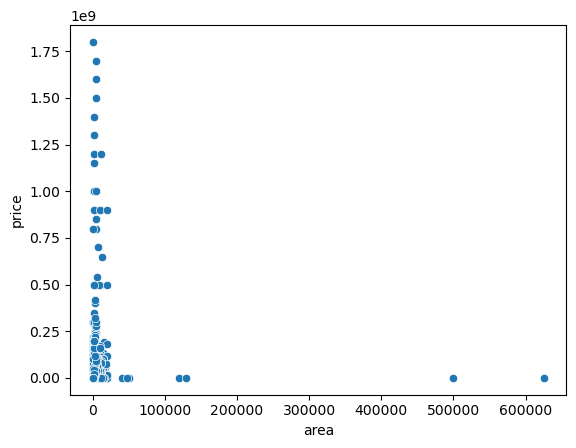

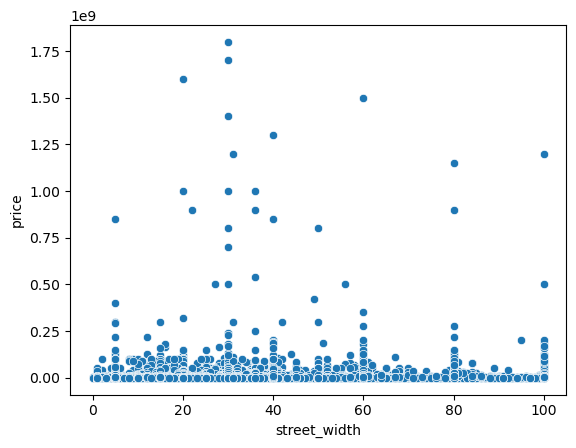

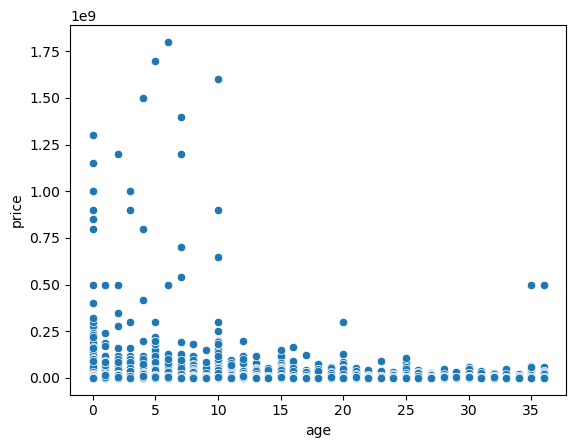

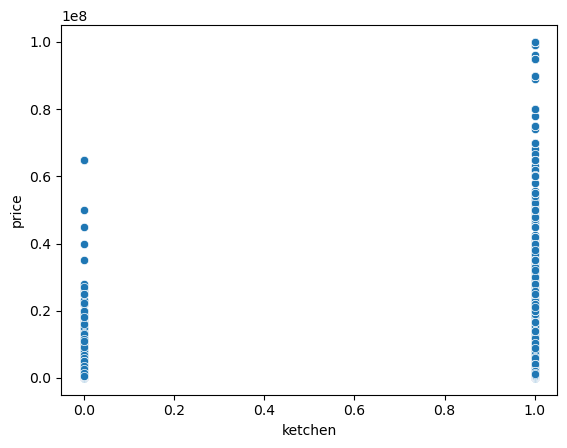

In [53]:
#scatter plot to understsnd the relationship
for i in ['beds', 'livings', 'wc', 'area', 'street_width', 'age', 'ketchen']:
    sns.scatterplot(data=df_res_sale,x=i,y='price')
    plt.show()

In [54]:
#correlation with heatmap to interpret the relation and multicollinearity
df_res_sale[['beds', 'livings', 'wc', 'area', 'street_width', 'age', 'ketchen', 'price']].corr()

,beds,livings,wc,area,street_width,age,ketchen,price
beds,1.000000,0.272113,0.460807,0.030877,-0.062084,0.046257,0.044163,0.102273
livings,0.272113,1.000000,0.482688,0.046130,-0.057621,0.071263,0.119240,0.253561
wc,0.460807,0.482688,1.000000,0.037129,-0.126331,-0.007702,0.100630,0.183422
area,0.030877,0.046130,0.037129,1.000000,0.033031,0.059821,0.046398,0.092030
street_width,-0.062084,-0.057621,-0.126331,0.033031,1.000000,-0.036336,-0.021486,0.086395
age,0.046257,0.071263,-0.007702,0.059821,-0.036336,1.000000,0.021042,0.041002
ketchen,0.044163,0.119240,0.100630,0.046398,-0.021486,0.021042,1.000000,0.050474
price,0.102273,0.253561,0.183422,0.092030,0.086395,0.041002,0.050474,1.000000


<Axes: >

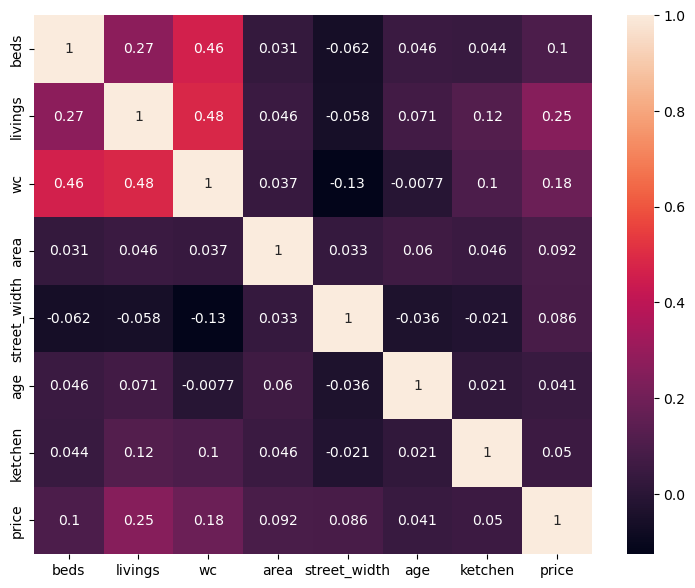

In [55]:
s=df_res_sale[['beds', 'livings', 'wc', 'area', 'street_width', 'age', 'ketchen', 'price']].corr()

plt.figure(figsize=(9,7))
sns.heatmap(s,annot=True)

### step:5] -Missing Value treatments

In [56]:
#finding missing value
df_res_sale.isnull().sum()

id                       0
createdAt                0
month                    0
week_day                 0
property_category        0
beds                 24514
livings              24358
wc                   24363
area                     7
street_width          3259
age                  25408
ketchen              36165
location.lat             0
location.lng             0
province                 0
city_id                  0
city                     0
city_en                  0
district_id              0
district                 0
district_en              0
price                    0
dtype: int64

In [57]:
#Percentage of missing values
df_res_sale.isnull().sum()/df_res_sale.shape[0]*100

id                    0.000000
createdAt             0.000000
month                 0.000000
week_day              0.000000
property_category     0.000000
beds                  7.966695
livings               7.915998
wc                    7.917623
area                  0.002275
street_width          1.059128
age                   8.257233
ketchen              11.753102
location.lat          0.000000
location.lng          0.000000
province              0.000000
city_id               0.000000
city                  0.000000
city_en               0.000000
district_id           0.000000
district              0.000000
district_en           0.000000
price                 0.000000
dtype: float64

In [58]:
# قائمة الأعمدة التي تحتاج معالجة القيم المفقودة في السكني
null_cols = ['beds', 'livings', 'wc', 'area', 'ketchen', 'age', 'street_width']

for col in null_cols:
    # بنملا القيم المفقودة بناءً على متوسط (Median) الحي ونوع العقار
    # الـ Median أفضل من الـ Mean هنا عشان نتفادى تأثير أي رقم غلط في الحي
    df_res_sale[col] = df_res_sale.groupby(['district_id', 'property_category'])[col].transform(
        lambda x: x.fillna(x.median() if not x.median() is np.nan else 0)
    )

# التأكد من عدم وجود نالز متبقية في السكني
print(df_res_sale[null_cols].isnull().sum()/df_res_sale.shape[0]*100)

beds            3.219307
livings         3.215407
wc              3.291129
area            0.000000
ketchen         4.257961
age             0.044198
street_width    0.016249
dtype: float64


In [59]:
# تنظيف ما تبقى من نالز بعد المحاولة الأولى
# لو ملقيناش متوسط للحي، هنحط 1 للغرف والحمامات (كحد أدنى للسكن) و 0 للباقي
df_res_sale['beds'] = df_res_sale['beds'].replace(0, 1).fillna(1)
df_res_sale['wc'] = df_res_sale['wc'].replace(0, 1).fillna(1)
df_res_sale.fillna(0, inplace=True) # للباقي زي العمر وعرض الشارع

print("Final Null Check:", df_res_sale.isnull().sum().sum())

Final Null Check: 0


In [60]:
#Percentage of missing values
df_res_sale.isnull().sum()/df_res_sale.shape[0]*100

id                   0.0
createdAt            0.0
month                0.0
week_day             0.0
property_category    0.0
beds                 0.0
livings              0.0
wc                   0.0
area                 0.0
street_width         0.0
age                  0.0
ketchen              0.0
location.lat         0.0
location.lng         0.0
province             0.0
city_id              0.0
city                 0.0
city_en              0.0
district_id          0.0
district             0.0
district_en          0.0
price                0.0
dtype: float64

### step:6]- Outliers treatments

In [61]:
def wisker(col):
    q1,q3=np.percentile(col,[25,75])
    iqr=q3-q1
    lw=q1-1.5*iqr
    uw=q3+1.5*iqr
    return lw,uw

In [62]:
for i in df_res_sale[['price', 'beds', 'livings', 'wc', 'area', 'street_width', 'age']]:
    lw,uw=wisker(df_res_sale[i])
    df_res_sale[i]=np.where(df_res_sale[i]<lw,lw,df_res_sale[i])
    df_res_sale[i]=np.where(df_res_sale[i]>uw,uw,df_res_sale[i])

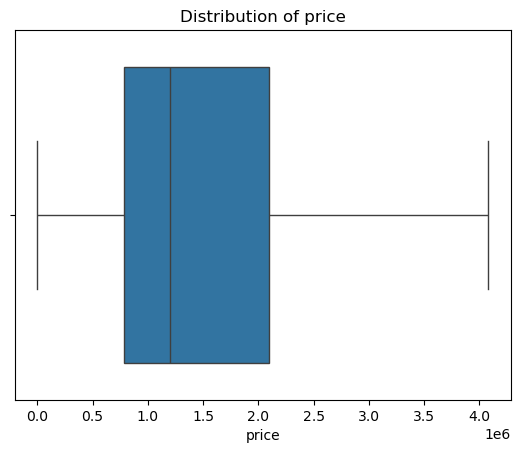

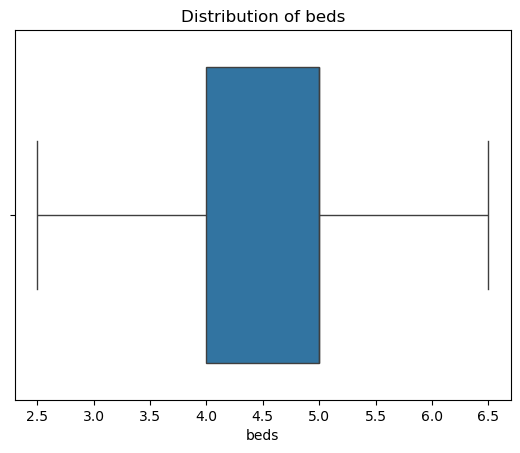

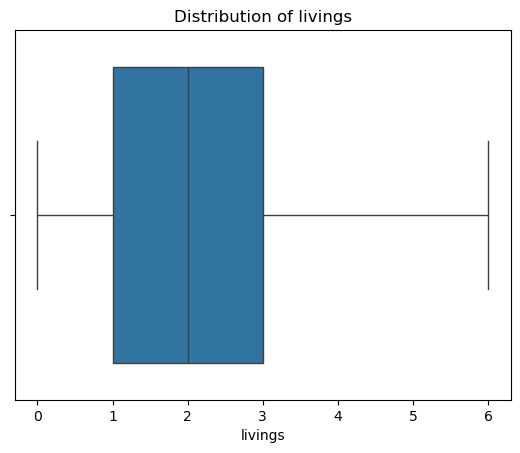

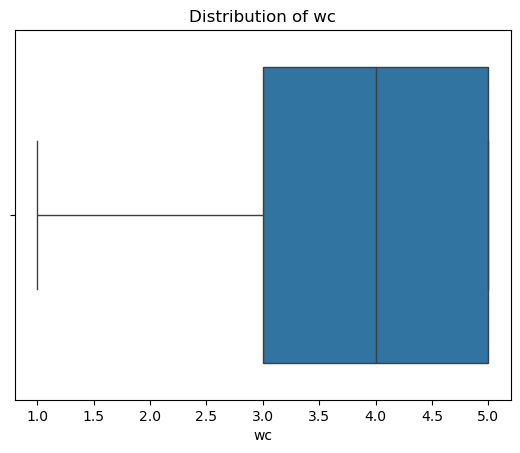

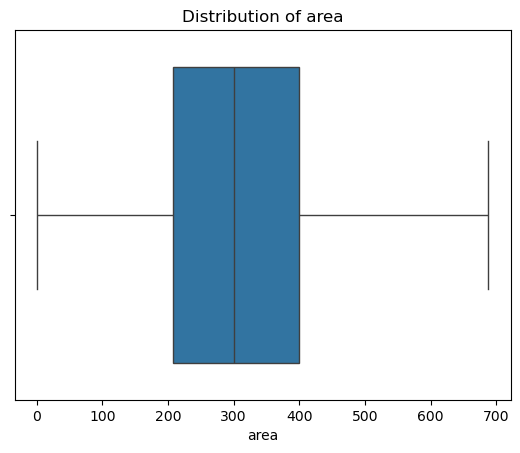

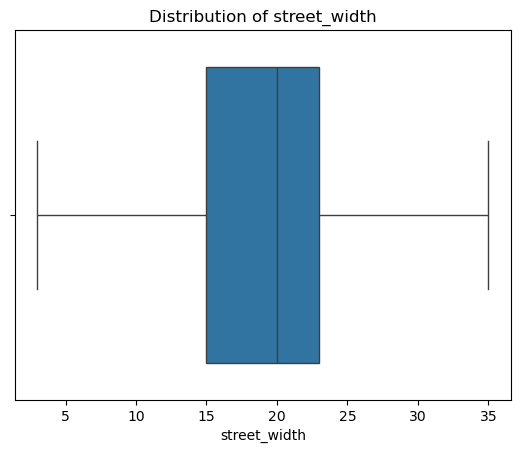

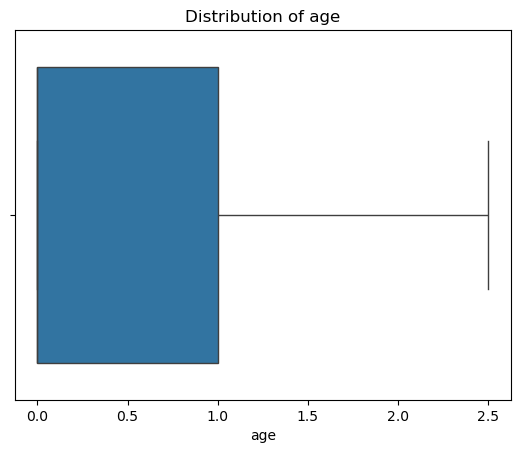

In [63]:
for i in ['price', 'beds', 'livings', 'wc', 'area', 'street_width', 'age']:
    sns.boxplot(data=df_res_sale,x=i)
    plt.title(f'Distribution of {i}')
    plt.show()

In [64]:
# 1. سعر المتر
df_res_sale['price_per_m2'] = df_res_sale['price'] / df_res_sale['area']

# 2. إجمالي الغرف والمرافق
df_res_sale['total_rooms'] = df_res_sale['beds'] + df_res_sale['livings'] + df_res_sale['wc']

# 3. تحويل المدن لـ Binary (الرياض vs الكل)
df_res_sale['is_riyadh'] = (df_res_sale['city_id'] == 21).astype(int) 

# 4. عمر العقار (تقسيم لفئات)
df_res_sale['is_new'] = (df_res_sale['age'] <= 1).astype(int)

# عرض أول 5 صفوف للتأكد من الأعمدة الجديدة
df_res_sale.head()

,id,createdAt,month,week_day,property_category,beds,livings,wc,area,street_width,age,ketchen,location.lat,location.lng,province,city_id,city,city_en,district_id,district,district_en,price,price_per_m2,total_rooms,is_riyadh,is_new
7,14155,2023-01-01,Jan,Sun,Villa,5.0,3.0,5.0,688.0,15.0,0.0,1.0,21.612269,39.138396,Makkah,66,جدة,Jeddah,3608,حي النهضة,Al Nahda neighborhood,4080000.0,5930.232558,13.0,0,1
11,24578,2023-01-01,Jan,Sun,Villa,5.0,1.0,3.0,400.0,30.0,0.0,1.0,21.386495,39.784993,Makkah,94,مكة المكرمة,Makkah,3766,حي الملك فهد,King Fahd neighborhood,1650000.0,4125.000000,9.0,0,1
13,24582,2023-01-01,Jan,Sun,Building,2.5,0.0,1.0,376.0,30.0,2.5,0.0,21.435731,39.849560,Makkah,94,مكة المكرمة,Makkah,3764,حي المعابدة,Al Maabdah neighborhood,4080000.0,10851.063830,3.5,0,0
16,40278,2023-01-01,Jan,Sun,Building,2.5,0.0,1.0,688.0,15.0,2.5,0.0,21.408780,39.789310,Makkah,94,مكة المكرمة,Makkah,3714,حي الرصيفة,Rusaifa neighborhood,4080000.0,5930.232558,3.5,0,0
19,50786,2023-01-01,Jan,Sun,Building,2.5,0.0,1.0,660.0,15.0,2.5,0.0,21.596930,39.132340,Makkah,66,جدة,Jeddah,3496,حي الزهراء,Al Zahra neighborhood,4080000.0,6181.818182,3.5,0,0


In [65]:
df_res_sale.select_dtypes(include="number").columns

Index(['id', 'beds', 'livings', 'wc', 'area', 'street_width', 'age', 'ketchen',
       'location.lat', 'location.lng', 'city_id', 'district_id', 'price',
       'price_per_m2', 'total_rooms', 'is_riyadh', 'is_new'],
      dtype='object')

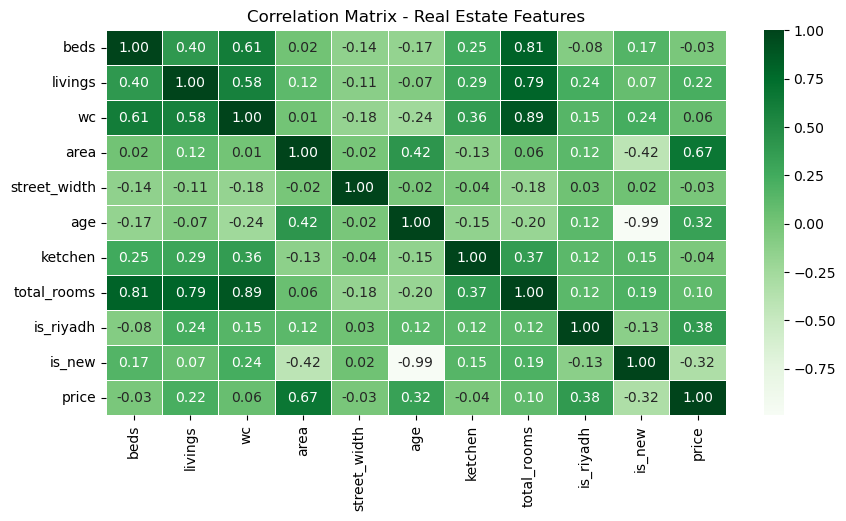

In [66]:
s = df_res_sale[['beds', 'livings', 'wc', 'area', 'street_width', 'age', 'ketchen', 'total_rooms', 'is_riyadh', 'is_new', 'price']].corr()

plt.figure(figsize=(10, 5))
sns.heatmap(s, annot=True, cmap='Greens', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix - Real Estate Features')
plt.show()

In [67]:
# تصدير الجدول النهائي لملف CSV
df_res_sale.to_csv('saudi_real_estate_sale.csv', index=False, encoding='utf-8-sig')

print("Done! الملف جاهز دلوقتي للتحميل واستخدامه في أي برنامج تحليل.")

Done! الملف جاهز دلوقتي للتحميل واستخدامه في أي برنامج تحليل.


### step:7]- Duplicates & Garbage value treatments

### step:8]- Normalization

### step:9]- Encoding of data

In [68]:
df_res_sale.select_dtypes(include=['object']).columns

Index(['createdAt', 'month', 'week_day', 'property_category', 'province',
       'city', 'city_en', 'district', 'district_en'],
      dtype='object')

In [69]:
# تحويل المتغيرات الفئوية أو النصية إلى أرقام (One-Hot Encoding)
dummy = pd.get_dummies(data=df, columns=['property_category', 'rent_period'], drop_first=True)
dummy.sample()

,id,createdAt,month,week_day,transaction_type,beds,livings,wc,area,street_width,age,ketchen,location.lat,location.lng,province,city_id,city,city_en,district_id,district,district_en,price,property_category_Building,property_category_Campsite,property_category_Chalet,property_category_Esteraha,property_category_Farm,property_category_Floor,property_category_Furnished Apartment,property_category_House,property_category_Land,property_category_Office,property_category_Room,property_category_Store,property_category_Villa,property_category_Warehouse,rent_period_Monthly,rent_period_Sale,rent_period_Yearly
40613,4241297,2023-01-01,Jan,Sun,Sale,NaN,NaN,NaN,840.0,28.0,NaN,NaN,25.010627,47.167242,Riyadh,21,الرياض,Riyadh,476,حي الشرق,Al Sharq neighborhood,453600.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
